In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

np.random.seed(0)

In [ ]:
def relu(x): 
    return np.maximum(0, x)

def drelu(x): 
    return (x > 0).astype(float)

def sigmoid(x): 
    return 1.0 / (1.0 + np.exp(-x))

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

In [45]:
def mse_loss(yhat, y): 
    return np.mean((yhat - y)**2)

def bce_loss(yhat, y, eps=1e-9):
    yhat = np.clip(yhat, eps, 1-eps)
    return -np.mean(y * np.log(yhat) + (1-y) * np.log(1-yhat))

def cce_loss(p, y_onehot, eps=1e-9):
    p = np.clip(p, eps, 1.0)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))

def init_params(din, dh, dout, scale=0.1):
    W1 = np.random.randn(din, dh) * scale
    b1 = np.zeros((1, dh))
    W2 = np.random.randn(dh, dout) * scale
    b2 = np.zeros((1, dout))
    print(f"W1:{W1.shape} b1:{b1.shape} W2:{W2.shape} b2:{b2.shape}")
    return W1, b1, W2, b2

In [46]:
ls = []
def train_regression_boston(epochs=200, lr=0.01):
    boston = fetch_openml(name="Boston", version=1, as_frame=False)
    X = StandardScaler().fit_transform(boston["data"])
    y = MinMaxScaler((0,1)).fit_transform(boston["target"].reshape(-1,1))
    W1,b1,W2,b2 = init_params(X.shape[1], 64, 1)
    for ep in range(1, epochs+1):
        h = relu(X @ W1 + b1)
        yhat = sigmoid(h @ W2 + b2)
        loss = mse_loss(yhat, y)
        # backprop
        N = X.shape[0]
        dloss = 2*(yhat - y)/N
        dz = dloss * (yhat * (1 - yhat))
        dW2 = h.T @ dz
        db2 = np.sum(dz, axis=0, keepdims=True)
        dh = dz @ W2.T
        dpre = dh * drelu(h)
        dW1 = X.T @ dpre
        db1 = np.sum(dpre, axis=0, keepdims=True)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
        ls.append(loss)
    plt.plot(ls)
    print(mse_loss(yhat, y))

In [47]:
def train_mnist_multiclass(epochs=5, lr=0.1):
    mn = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mn["data"].astype(np.float32) / 255.0
    y = mn["target"].astype(int)
    X = StandardScaler().fit_transform(X)
    enc = OneHotEncoder(sparse_output=False)
    yoh = enc.fit_transform(y.reshape(-1,1))
    W1,b1,W2,b2 = init_params(X.shape[1], 128, yoh.shape[1], scale=0.05)
    N = X.shape[0]
    for ep in range(1, epochs+1):
        h = relu(X @ W1 + b1)
        logits = h @ W2 + b2
        p = softmax(logits)
        loss = cce_loss(p, yoh)
        dz = (p - yoh) / N
        dW2 = h.T @ dz
        db2 = np.sum(dz, axis=0, keepdims=True)
        dh = dz @ W2.T
        dpre = dh * drelu(h)
        dW1 = X.T @ dpre
        db1 = np.sum(dpre, axis=0, keepdims=True)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
        ls.append(loss)
    plt.plot(ls)
    print(cce_loss(p, yoh))

In [48]:
def train_pima_binary(epochs=300, lr=0.01):
    data = fetch_openml("pima-indians-diabetes", version=1, as_frame=False)
    X = StandardScaler().fit_transform(data["data"])
    y = data["target"].astype(float).reshape(-1,1)
    W1,b1,W2,b2 = init_params(X.shape[1], 32, 1)
    N = X.shape[0]
    for ep in range(1, epochs+1):
        h = relu(X @ W1 + b1)
        yhat = sigmoid(h @ W2 + b2)
        loss = bce_loss(yhat, y)
        dz = (yhat - y) / N
        dW2 = h.T @ dz
        db2 = np.sum(dz, axis=0, keepdims=True)
        dh = dz @ W2.T
        dpre = dh * drelu(h)
        dW1 = X.T @ dpre
        db1 = np.sum(dpre, axis=0, keepdims=True)
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1
        ls.append(loss)
    plt.plot(ls)
    print(bce_loss(yhat, y))

W1:(13, 64) b1:(1, 64) W2:(64, 1) b2:(1, 1)
0.035408215988518885


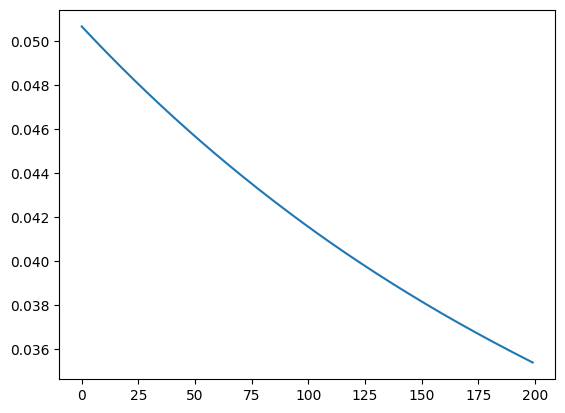

In [49]:
train_regression_boston()

W1:(784, 128) b1:(1, 128) W2:(128, 10) b2:(1, 10)
1.8660263342640633


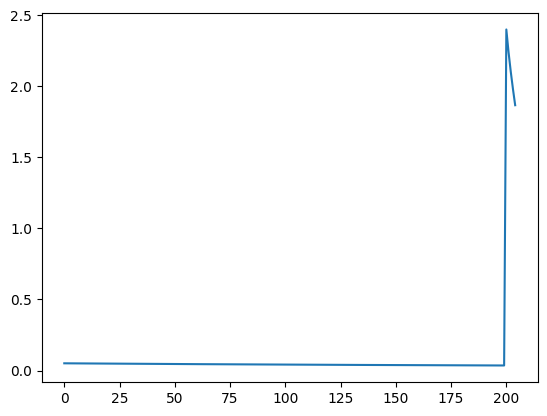

In [50]:
train_mnist_multiclass()

W1:(8, 32) b1:(1, 32) W2:(32, 1) b2:(1, 1)
0.5743062504611781


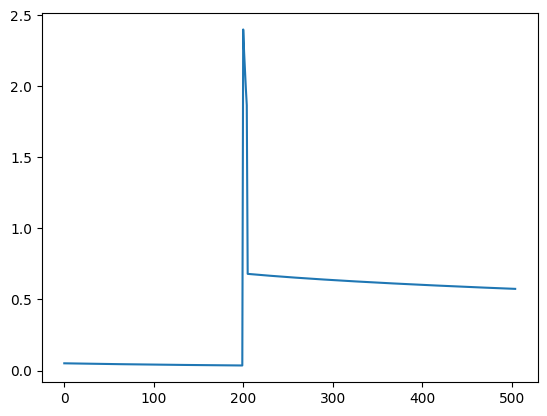

In [51]:
train_pima_binary()